In [11]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
import random

In [12]:
X , y = make_classification(n_features=5,n_redundant=0,n_informative=5,n_clusters_per_class=1)

In [13]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,-1.916704,2.722378,0.348600,2.749881,-0.007505,0
1,-0.593847,0.237537,0.890129,-1.675074,-2.772781,1
2,-0.331177,0.308615,0.030260,-0.302606,-1.719231,1
3,-2.539407,1.669645,-1.417471,-0.460557,-2.808732,1
4,-0.693243,0.889763,-2.012166,-0.115776,-1.823159,1


In [21]:
# Function for Row Sampling
def sample_rows(df,percent):
  return df.sample(int(percent * df.shape[0]),replace=True)

In [22]:
# Function for Feature Sampling
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent * (df.shape[1]-1)))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df

In [23]:
# Function for Combined Sampling
def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

In [24]:
df1 = combined_sampling(df,0.5,0.5)

<ipython-input-22-7c1e1898af08>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [25]:
df2 = combined_sampling(df,0.5,0.5)

<ipython-input-22-7c1e1898af08>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [26]:
df3 = combined_sampling(df,0.5,0.5)

<ipython-input-22-7c1e1898af08>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [29]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col5', 'col3', 'target'], dtype='object')
Index(['col1', 'col3', 'target'], dtype='object')
Index(['col2', 'col3', 'target'], dtype='object')


In [30]:
df3

,col2,col3,target
79,2.617859,-1.394933,0
65,-1.454902,-1.278416,1
15,-0.867929,-1.791186,1
44,-2.527065,-1.629957,1
24,-3.011350,-1.508654,1
57,0.155329,4.470509,0
59,-0.129883,-1.322410,1
36,-0.943370,3.758286,0
77,-2.083509,-0.522163,1
68,-1.424782,2.477605,0


In [32]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [33]:
clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

DecisionTreeClassifier()

In [34]:
from sklearn.tree import plot_tree

[Text(0.38461538461538464, 0.9, 'x[0] <= -0.575\ngini = 0.5\nsamples = 50\nvalue = [25, 25]'),
 Text(0.15384615384615385, 0.7, 'x[1] <= 1.012\ngini = 0.095\nsamples = 20\nvalue = [1, 19]'),
 Text(0.2692307692307693, 0.8, 'True  '),
 Text(0.07692307692307693, 0.5, 'gini = 0.0\nsamples = 19\nvalue = [0, 19]'),
 Text(0.23076923076923078, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.6153846153846154, 0.7, 'x[1] <= -0.673\ngini = 0.32\nsamples = 30\nvalue = [24, 6]'),
 Text(0.5, 0.8, '  False'),
 Text(0.38461538461538464, 0.5, 'x[0] <= 0.571\ngini = 0.469\nsamples = 8\nvalue = [3, 5]'),
 Text(0.3076923076923077, 0.3, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.46153846153846156, 0.3, 'x[1] <= -1.217\ngini = 0.375\nsamples = 4\nvalue = [3, 1]'),
 Text(0.38461538461538464, 0.1, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.5384615384615384, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.8461538461538461, 0.5, 'x[0] <= -0.478\ngini = 0.087\nsamples = 22\nval

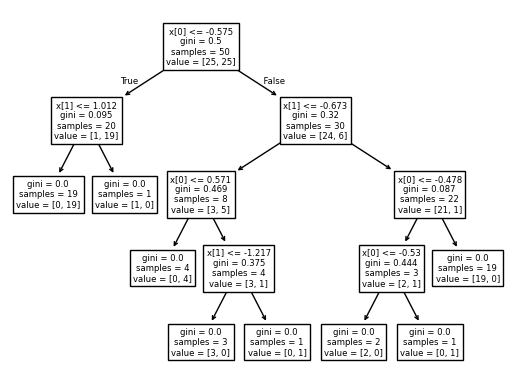

In [35]:
plot_tree(clf1)

[Text(0.5, 0.9166666666666666, 'x[0] <= -0.86\ngini = 0.497\nsamples = 50\nvalue = [27, 23]'),
 Text(0.2727272727272727, 0.75, 'x[1] <= -1.328\ngini = 0.095\nsamples = 20\nvalue = [19, 1]'),
 Text(0.38636363636363635, 0.8333333333333333, 'True  '),
 Text(0.18181818181818182, 0.5833333333333334, 'x[1] <= -2.205\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.09090909090909091, 0.4166666666666667, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.2727272727272727, 0.4166666666666667, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.36363636363636365, 0.5833333333333334, 'gini = 0.0\nsamples = 18\nvalue = [18, 0]'),
 Text(0.7272727272727273, 0.75, 'x[1] <= 1.461\ngini = 0.391\nsamples = 30\nvalue = [8, 22]'),
 Text(0.6136363636363636, 0.8333333333333333, '  False'),
 Text(0.6363636363636364, 0.5833333333333334, 'x[1] <= 0.36\ngini = 0.211\nsamples = 25\nvalue = [3, 22]'),
 Text(0.45454545454545453, 0.4166666666666667, 'x[0] <= 2.253\ngini = 0.095\nsamples = 20\nvalue = [1, 19]'),

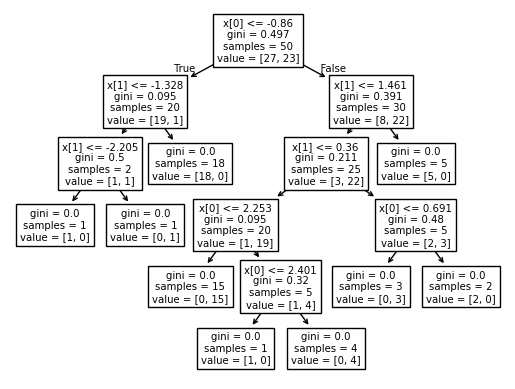

In [36]:
plot_tree(clf2)

[Text(0.5555555555555556, 0.9166666666666666, 'x[1] <= -0.329\ngini = 0.499\nsamples = 50\nvalue = [24, 26]'),
 Text(0.3333333333333333, 0.75, 'x[0] <= 1.918\ngini = 0.375\nsamples = 32\nvalue = [8, 24]'),
 Text(0.4444444444444444, 0.8333333333333333, 'True  '),
 Text(0.2222222222222222, 0.5833333333333334, 'x[0] <= 0.732\ngini = 0.142\nsamples = 26\nvalue = [2, 24]'),
 Text(0.1111111111111111, 0.4166666666666667, 'gini = 0.0\nsamples = 20\nvalue = [0, 20]'),
 Text(0.3333333333333333, 0.4166666666666667, 'x[1] <= -2.503\ngini = 0.444\nsamples = 6\nvalue = [2, 4]'),
 Text(0.2222222222222222, 0.25, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.4444444444444444, 0.25, 'x[1] <= -1.045\ngini = 0.32\nsamples = 5\nvalue = [1, 4]'),
 Text(0.3333333333333333, 0.08333333333333333, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.5555555555555556, 0.08333333333333333, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.4444444444444444, 0.5833333333333334, 'gini = 0.0\nsamples = 6\nvalue

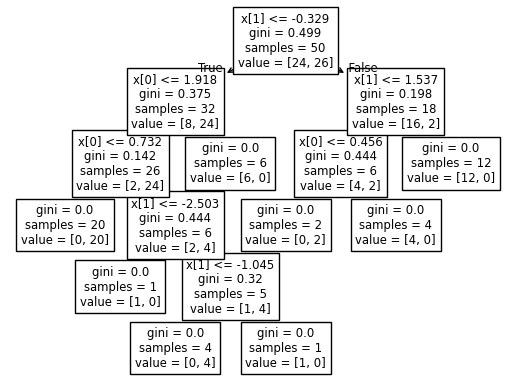

In [37]:
plot_tree(clf3)

In [38]:
clf1.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [39]:
clf2.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [40]:
clf3.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [41]:
df.sample(14,replace=True)

,col1,col2,col3,col4,col5,target
33,1.884024,-1.260656,-1.879882,0.843717,1.047234,1
42,-1.705410,-0.909587,2.064648,2.040606,-1.207087,0
44,1.875044,-2.527065,-1.629957,-0.608019,-1.224692,1
55,-5.076737,-0.812758,-0.516733,-1.040046,-0.573792,0
46,-3.083986,1.277298,-0.083549,0.145582,0.475336,0
16,0.218814,-0.021299,-2.611639,0.364843,-1.659990,1
92,-2.023725,0.864160,1.993707,4.013464,-1.479305,0
93,-0.319792,-0.524964,-2.440182,-0.916753,-2.094152,1
47,-1.262751,1.167577,-1.238437,2.142610,0.762038,0
25,0.274153,-0.085931,-2.098289,-1.089945,-1.821768,1
